In [694]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/city_day.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (29531, 16)

Columns:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']


In [695]:
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Data Types:
City              str
Date              str
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket        str
dtype: object

Missing Values:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


In [696]:
missing = df.isnull().sum().sort_values(ascending=False)

missing_percent = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing %": missing_percent
})

missing_table

,Missing Values,Missing %
Xylene,18109,61.32
PM10,11140,37.72
NH3,10328,34.97
Toluene,8041,27.23
Benzene,5623,19.04
AQI,4681,15.85
AQI_Bucket,4681,15.85
PM2.5,4598,15.57
NOx,4185,14.17
O3,4022,13.62


In [697]:
df["Date"] = pd.to_datetime(df["Date"])

print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())
print("Number of Cities:", df["City"].nunique())

print("\nCities:")
print(df["City"].unique())

Start Date: 2015-01-01 00:00:00
End Date: 2020-07-01 00:00:00
Number of Cities: 26

Cities:
<StringArray>
[         'Ahmedabad',             'Aizawl',          'Amaravati',
           'Amritsar',          'Bengaluru',             'Bhopal',
       'Brajrajnagar',         'Chandigarh',            'Chennai',
         'Coimbatore',              'Delhi',          'Ernakulam',
           'Gurugram',           'Guwahati',          'Hyderabad',
             'Jaipur',         'Jorapokhar',              'Kochi',
            'Kolkata',            'Lucknow',             'Mumbai',
              'Patna',           'Shillong',            'Talcher',
 'Thiruvananthapuram',      'Visakhapatnam']
Length: 26, dtype: str


In [698]:
df_2015_2019 = df[
    (df["Date"] >= "2015-01-01") &
    (df["Date"] < "2020-01-01")
].copy()

print("2015–2019 Dataset Shape:", df_2015_2019.shape)
print("Start:", df_2015_2019["Date"].min())
print("End:", df_2015_2019["Date"].max())

2015–2019 Dataset Shape: (24885, 16)
Start: 2015-01-01 00:00:00
End: 2019-12-31 00:00:00


In [699]:
# Missing values in 2015-2019 dataset

missing_2015_2019 = df_2015_2019.isnull().sum().sort_values(ascending=False)

missing_2015_2019

Xylene        15330
PM10          10777
NH3            9801
Toluene        6719
Benzene        4827
AQI            4456
AQI_Bucket     4456
PM2.5          4430
NOx            3911
O3             3681
SO2            3667
NO             3356
NO2            3355
CO             1875
Date              0
City              0
dtype: int64

In [700]:
# Statistical Summary of Numerical Features

numeric_cols = df_2015_2019.select_dtypes(include="number").columns

summary_stats = df_2015_2019[numeric_cols].describe().T

summary_stats

,count,mean,std,min,25%,50%,75%,max
PM2.5,20455.0,72.603877,68.386340,0.04,31.5200,52.490,86.4800,949.99
PM10,14108.0,126.736172,95.854653,0.01,61.4900,101.810,158.8550,1000.00
NO,21529.0,17.665298,21.962084,0.02,6.0700,10.220,20.0700,287.14
NO2,21530.0,30.212931,25.500237,0.01,12.7600,23.275,39.3700,362.21
NOx,20974.0,33.126378,31.893429,0.00,13.4600,24.580,41.1875,467.63
NH3,15084.0,24.718158,27.574910,0.01,8.5875,16.685,31.1400,352.89
CO,23010.0,2.458919,7.422407,0.00,0.5300,0.930,1.5300,175.81
SO2,21218.0,15.078946,19.411479,0.04,5.4825,9.110,15.6700,193.86
O3,21204.0,34.460954,22.232062,0.01,18.4000,30.280,45.4500,257.73
Benzene,20058.0,2.814354,9.355060,0.00,0.1100,1.010,3.0700,391.88


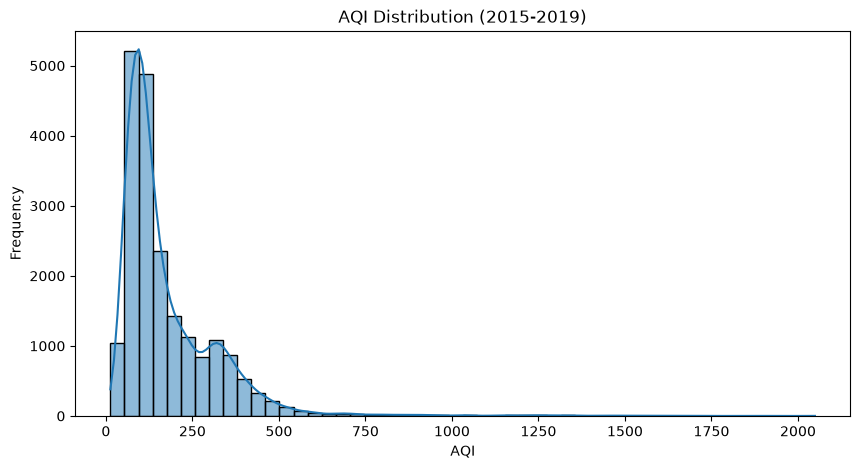

In [702]:
# Distribution of AQI

plt.figure(figsize=(10, 5))

sns.histplot(df_2015_2019["AQI"].dropna(), bins=50, kde=True)

plt.title("AQI Distribution (2015-2019)")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

In [703]:
# Average AQI by City

city_aqi = (
    df_2015_2019.groupby("City")["AQI"]
    .mean()
    .sort_values(ascending=False)
)

city_aqi

City
Ahmedabad             484.048359
Delhi                 267.329295
Patna                 252.044671
Gurugram              234.701575
Lucknow               224.484795
Talcher               176.396679
Jorapokhar            162.952381
Bhopal                162.609524
Brajrajnagar          152.972973
Kolkata               148.024518
Jaipur                139.416026
Chandigarh            135.547009
Guwahati              127.560897
Amritsar              124.845588
Visakhapatnam         123.110775
Chennai               118.187537
Hyderabad             112.553919
Mumbai                105.903716
Amaravati             105.150456
Bengaluru              95.865663
Thiruvananthapuram     77.860759
Coimbatore             77.026596
Shillong               44.476190
Name: AQI, dtype: float64

In [704]:
ahmedabad_aqi = df_2015_2019[
    df_2015_2019["City"] == "Ahmedabad"
]["AQI"].dropna()

print("Count:", len(ahmedabad_aqi))
print("Mean:", ahmedabad_aqi.mean())
print("Median:", ahmedabad_aqi.median())
print("Min:", ahmedabad_aqi.min())
print("Max:", ahmedabad_aqi.max())

print("\nPercentiles:")
print(ahmedabad_aqi.quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

Count: 1158
Mean: 484.0483592400691
Median: 414.0
Min: 48.0
Max: 2049.0

Percentiles:
0.25     267.00
0.50     414.00
0.75     574.75
0.90     898.90
0.95    1201.60
0.99    1559.29
Name: AQI, dtype: float64


In [705]:
print(df_2015_2019["AQI"].max())

print(
    df_2015_2019.loc[
        df_2015_2019["AQI"] > 500,
        ["City", "Date", "AQI"]
    ].sort_values("AQI", ascending=False).head(20)
)

2049.0
           City       Date     AQI
1145  Ahmedabad 2018-02-19  2049.0
1136  Ahmedabad 2018-02-10  1917.0
560   Ahmedabad 2016-07-14  1842.0
1048  Ahmedabad 2017-11-14  1747.0
1463  Ahmedabad 2019-01-03  1719.0
1417  Ahmedabad 2018-11-18  1672.0
1420  Ahmedabad 2018-11-21  1646.0
1407  Ahmedabad 2018-11-08  1630.0
1127  Ahmedabad 2018-02-01  1613.0
1746  Ahmedabad 2019-10-13  1595.0
1047  Ahmedabad 2017-11-13  1577.0
1391  Ahmedabad 2018-10-23  1561.0
1451  Ahmedabad 2018-12-22  1558.0
1412  Ahmedabad 2018-11-13  1548.0
1481  Ahmedabad 2019-01-21  1537.0
1149  Ahmedabad 2018-02-23  1526.0
1148  Ahmedabad 2018-02-22  1483.0
1144  Ahmedabad 2018-02-18  1477.0
1461  Ahmedabad 2019-01-01  1474.0
1418  Ahmedabad 2018-11-19  1472.0


In [706]:
df_2015_2019[
    (df_2015_2019["City"] == "Ahmedabad") &
    (df_2015_2019["AQI"] > 500)
][["City", "Date", "PM2.5", "PM10", "NO2", "CO", "SO2", "O3", "AQI"]].head(20)

,City,Date,PM2.5,PM10,NO2,CO,SO2,O3,AQI
30,Ahmedabad,2015-01-31,94.52,NaN,32.66,24.39,67.39,111.33,514.0
31,Ahmedabad,2015-02-01,135.99,NaN,42.08,43.48,75.23,102.70,782.0
32,Ahmedabad,2015-02-02,178.33,NaN,35.31,54.56,55.04,107.38,914.0
33,Ahmedabad,2015-02-03,139.70,NaN,28.40,30.61,33.79,73.60,660.0
43,Ahmedabad,2015-02-13,103.36,NaN,39.56,18.18,80.43,40.11,510.0
44,Ahmedabad,2015-02-14,177.33,NaN,47.58,37.49,99.72,36.47,761.0
46,Ahmedabad,2015-02-16,99.70,NaN,28.10,19.85,73.23,30.57,536.0
48,Ahmedabad,2015-02-18,100.79,NaN,25.93,16.24,43.11,37.43,592.0
50,Ahmedabad,2015-02-20,140.29,NaN,36.14,33.84,101.53,40.98,588.0
51,Ahmedabad,2015-02-21,239.96,NaN,46.25,61.95,84.87,33.55,1141.0


In [707]:
ahmedabad_aqi = df_2015_2019[
    df_2015_2019["City"] == "Ahmedabad"
]["AQI"]

print("Ahmedabad AQI > 500:", (ahmedabad_aqi > 500).sum())
print("Ahmedabad AQI > 1000:", (ahmedabad_aqi > 1000).sum())
print("Ahmedabad Maximum AQI:", ahmedabad_aqi.max())

Ahmedabad AQI > 500: 395
Ahmedabad AQI > 1000: 90
Ahmedabad Maximum AQI: 2049.0


In [708]:
# Remove suspiciously high AQI values
df_clean = df_2015_2019[df_2015_2019["AQI"] <= 500].copy()

print("Original rows:", df_2015_2019.shape[0])
print("Cleaned rows:", df_clean.shape[0])
print("Removed rows:", df_2015_2019.shape[0] - df_clean.shape[0])

Original rows: 24885
Cleaned rows: 19903
Removed rows: 4982


In [709]:
# Missing values after cleaning
missing_clean = (
    df_clean.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_clean

Xylene        12716
PM10           6446
NH3            5679
Toluene        4619
Benzene        2817
NOx            1652
PM2.5           612
O3              538
SO2             505
CO              332
NO              269
NO2             266
Date              0
City              0
AQI               0
AQI_Bucket        0
dtype: int64

In [710]:
print("Missing AQI:", df_clean["AQI"].isnull().sum())
print("Total rows:", len(df_clean))

Missing AQI: 0
Total rows: 19903


In [711]:
# Average AQI by City after cleaning

city_aqi_clean = (
    df_clean.groupby("City")["AQI"]
    .mean()
    .sort_values(ascending=False)
)

city_aqi_clean

City
Ahmedabad             314.129751
Delhi                 259.395362
Patna                 246.275779
Gurugram              228.315705
Lucknow               221.463127
Talcher               173.767658
Bhopal                162.609524
Jorapokhar            158.342193
Brajrajnagar          152.972973
Kolkata               148.024518
Jaipur                139.416026
Chandigarh            135.547009
Visakhapatnam         123.110775
Guwahati              122.596774
Amritsar              122.381857
Chennai               118.187537
Hyderabad             111.396338
Mumbai                105.903716
Amaravati             105.150456
Bengaluru              95.865663
Thiruvananthapuram     77.860759
Coimbatore             77.026596
Shillong               44.476190
Name: AQI, dtype: float64

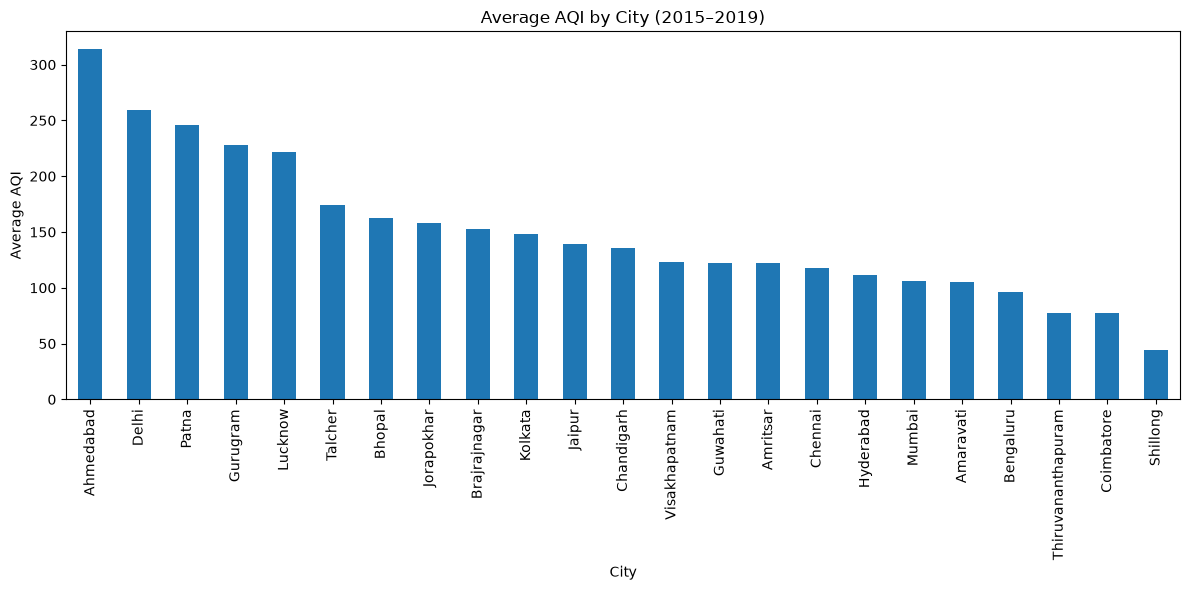

In [712]:
plt.figure(figsize=(12, 6))

city_aqi_clean.plot(kind="bar")

plt.title("Average AQI by City (2015–2019)")
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

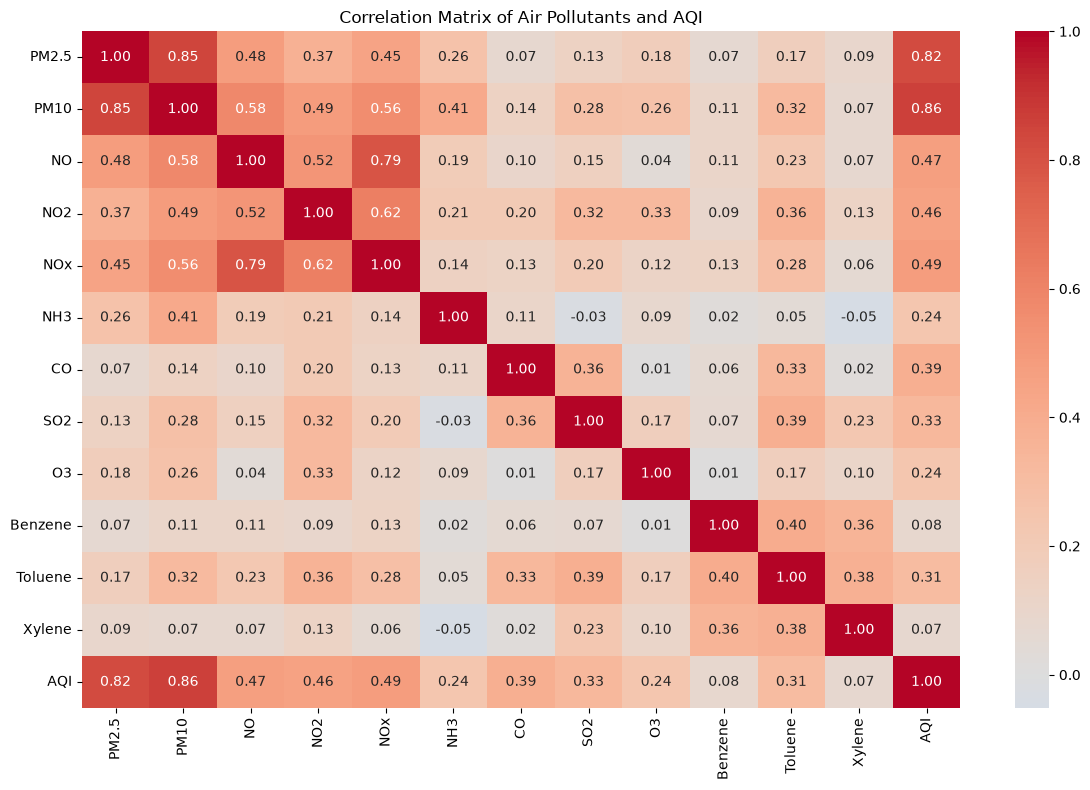

In [713]:
# Correlation between pollutants and AQI

corr_cols = [
    "PM2.5", "PM10", "NO", "NO2", "NOx",
    "NH3", "CO", "SO2", "O3",
    "Benzene", "Toluene", "Xylene", "AQI"
]

correlation = df_clean[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Air Pollutants and AQI")
plt.tight_layout()
plt.show()

In [714]:
# Correlation matrix
corr_matrix = df.select_dtypes(include="number").corr()

# Top correlations with AQI
aqi_corr = corr_matrix["AQI"].drop("AQI").sort_values(ascending=False)

print("Correlations with AQI:")
display(aqi_corr.to_frame(name="Correlation"))

Correlations with AQI:


,Correlation
PM10,0.803313
CO,0.683346
PM2.5,0.659181
NO2,0.537071
SO2,0.490586
NOx,0.486450
NO,0.452191
Toluene,0.279992
NH3,0.252019
O3,0.198991


In [715]:
# Handle missing values

numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after cleaning:")
display(df.isnull().sum())

Missing values after cleaning:


City             0
Date             0
PM2.5            0
PM10             0
NO               0
NO2              0
NOx              0
NH3              0
CO               0
SO2              0
O3               0
Benzene          0
Toluene          0
Xylene           0
AQI              0
AQI_Bucket    4681
dtype: int64

In [716]:
# Save cleaned dataset

df.to_csv("../data/city_day_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")
print("Shape:", df.shape)

Cleaned dataset saved successfully!
Shape: (29531, 16)


In [718]:
# Average AQI by city

city_risk = (
    df.groupby("City")["AQI"]
      .mean()
      .sort_values(ascending=False)
      .to_frame("Average AQI")
)

display(city_risk)

,Average AQI
City,
Ahmedabad,339.861623
Delhi,258.783474
Patna,214.414962
Lucknow,212.200597
Gurugram,210.704586
Talcher,159.417297
Jorapokhar,145.207015
Brajrajnagar,142.537313
Guwahati,139.802789


In [723]:
selected_cities = [
    "Delhi",
    "Mumbai",
    "Bengaluru",
    "Chennai",
    "Lucknow"
]

df_5 = df[df["City"].isin(selected_cities)].copy()

print("Selected Cities:")
print(df_5["City"].unique())

print("\nDataset Shape:", df_5.shape)

Selected Cities:
<StringArray>
['Bengaluru', 'Chennai', 'Delhi', 'Lucknow', 'Mumbai']
Length: 5, dtype: str

Dataset Shape: (10045, 16)


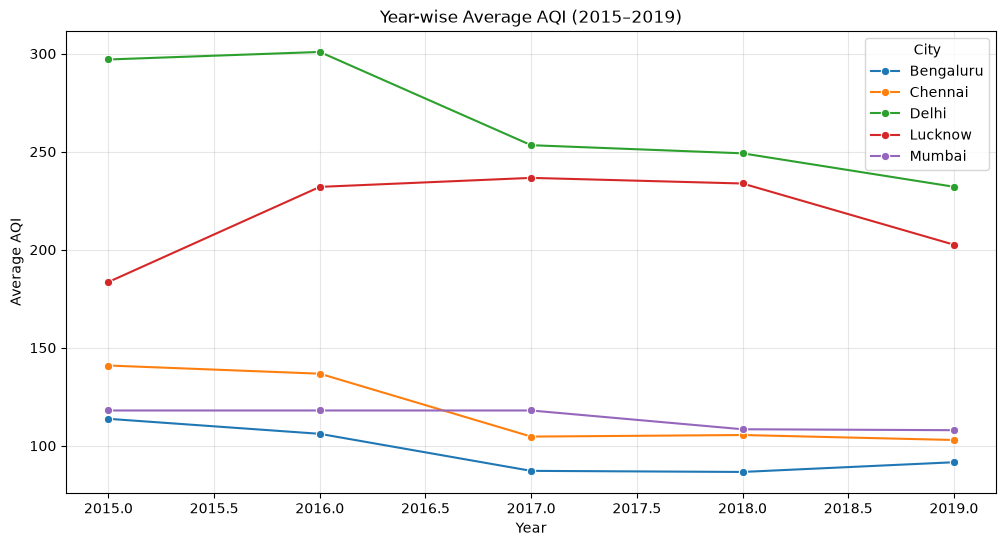

In [724]:
yearly_aqi = (
    df_5[df_5["Date"].dt.year.between(2015, 2019)]
    .assign(Year=lambda x: x["Date"].dt.year)
    .groupby(["Year", "City"])["AQI"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=yearly_aqi,
    x="Year",
    y="AQI",
    hue="City",
    marker="o"
)

plt.title("Year-wise Average AQI (2015–2019)")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.grid(alpha=0.3)
plt.show()

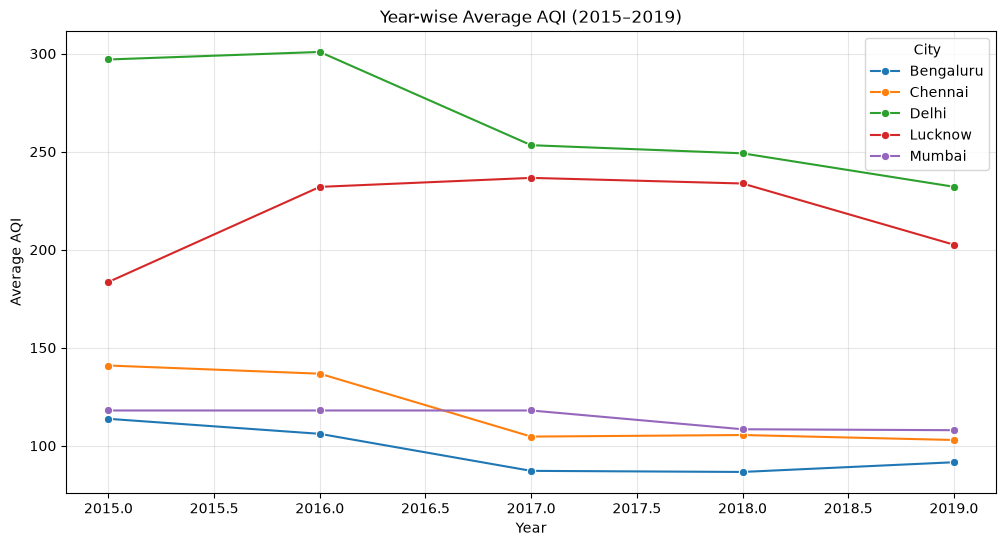

In [725]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=yearly_aqi,
    x="Year",
    y="AQI",
    hue="City",
    marker="o"
)

plt.title("Year-wise Average AQI (2015–2019)")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.grid(alpha=0.3)
plt.legend(title="City")
plt.show()

In [727]:
# AQI Risk Category Distribution (%)

risk_data = (
    df_5.groupby(["City", "AQI_Bucket"])
    .size()
    .reset_index(name="Days")
)

risk_data["Percentage"] = (
    risk_data.groupby("City")["Days"]
    .transform(lambda x: (x / x.sum()) * 100)
)

risk_pivot = (
    risk_data
    .pivot(index="City", columns="AQI_Bucket", values="Percentage")
    .fillna(0)
)

display(risk_pivot.round(2))

AQI_Bucket,Good,Moderate,Poor,Satisfactory,Severe,Very Poor
City,,,,,,
Bengaluru,6.02,32.98,1.88,58.85,0.00,0.26
Chennai,0.64,42.68,5.84,49.95,0.32,0.58
Delhi,1.05,25.96,27.11,7.90,11.96,26.01
Lucknow,0.79,30.53,18.59,19.28,5.81,24.99
Mumbai,3.35,36.77,4.52,55.23,0.00,0.13


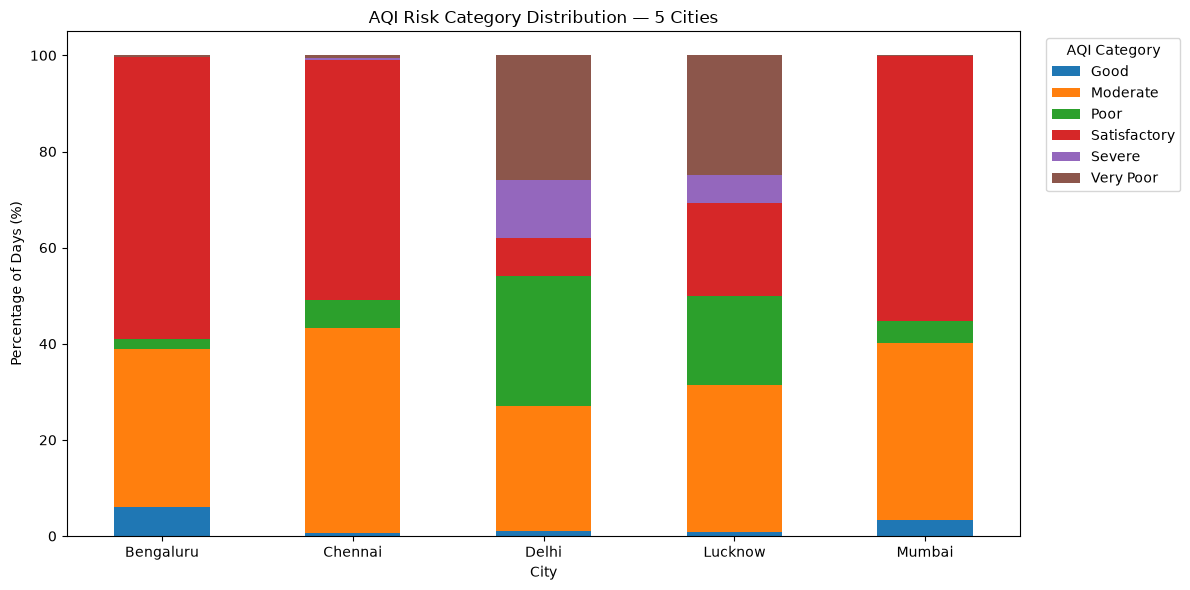

In [728]:
# Stacked bar chart

risk_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("AQI Risk Category Distribution — 5 Cities")
plt.xlabel("City")
plt.ylabel("Percentage of Days (%)")
plt.legend(title="AQI Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

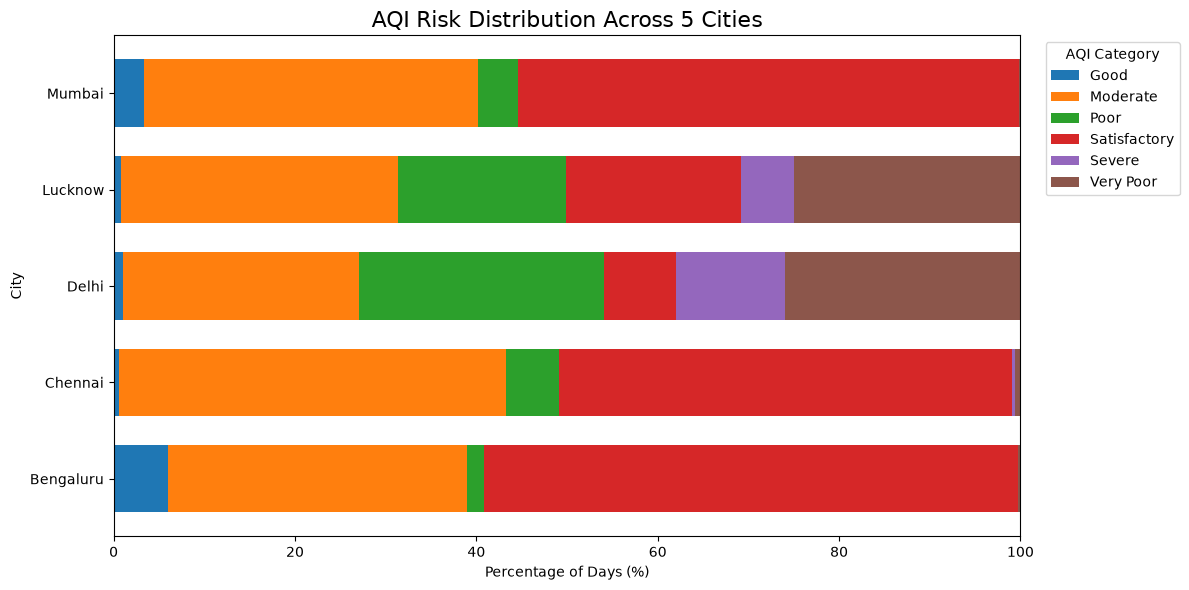

In [729]:
# Better Risk Distribution Graph

risk_pivot.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 6),
    width=0.7
)

plt.title("AQI Risk Distribution Across 5 Cities", fontsize=16)
plt.xlabel("Percentage of Days (%)")
plt.ylabel("City")

plt.xlim(0, 100)
plt.legend(
    title="AQI Category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [730]:
# Final 5-city pollution dataset

final_pollution = df_5[
    [
        "City",
        "Date",
        "AQI",
        "AQI_Bucket",
        "PM2.5",
        "PM10",
        "NO2",
        "CO",
        "SO2",
        "O3"
    ]
].copy()

# Save CSV
final_pollution.to_csv(
    "../data/final_pollution_5cities.csv",
    index=False
)

print("✅ Final 5-city CSV created!")
print("Rows:", final_pollution.shape[0])
print("Columns:", final_pollution.shape[1])
print("\nCities:")
print(final_pollution["City"].unique())

✅ Final 5-city CSV created!
Rows: 10045
Columns: 10

Cities:
<StringArray>
['Bengaluru', 'Chennai', 'Delhi', 'Lucknow', 'Mumbai']
Length: 5, dtype: str
